#  Análisis Exploratorio de Datos — Telco Customer Churn
**Dataset:** WA_Fn-UseC_-Telco-Customer-Churn  
**Registros:** 7 043 clientes · **Variables:** 21  
**Objetivo:** Comprender los factores asociados al abandono de clientes (Churn)

---
> *"Los datos tienen una historia que contar. El EDA es el arte de escucharla."*

---

## 0. Configuración del entorno

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency
from IPython.display import display, HTML
import warnings
warnings.filterwarnings('ignore')

# ── Paleta profesional ────────────────────────────────────────
COLOR_NO   = '#2ECC71'   # Verde  → No Churn
COLOR_YES  = '#E74C3C'   # Rojo   → Churn
COLOR_MAIN = '#2C3E50'   # Azul oscuro
PALETTE    = [COLOR_NO, COLOR_YES]

plt.rcParams.update({
    'figure.facecolor':  'white',
    'axes.facecolor':    '#F8F9FA',
    'axes.edgecolor':    '#DEE2E6',
    'axes.linewidth':    1.2,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'grid.color':        '#DEE2E6',
    'grid.linestyle':    '--',
    'grid.alpha':        0.6,
    'font.family':       'DejaVu Sans',
    'axes.titlesize':    13,
    'axes.titleweight':  'bold',
    'axes.labelsize':    11,
    'xtick.labelsize':   9,
    'ytick.labelsize':   9,
})


def display_table(df, caption=None):
    if caption:
        display(HTML(f"<div style='font-family: DejaVu Sans; color: {COLOR_MAIN}; font-size: 1rem; font-weight: 700; margin-bottom: 0.35rem;'>{caption}</div>"))

    styles = [
        {'selector': 'thead', 'props': [('background-color', COLOR_MAIN), ('color', 'white'), ('font-weight', 'bold')]},
        {'selector': 'tbody tr:nth-child(even)', 'props': [('background-color', '#F8F9FA')]},
        {'selector': 'tbody tr:hover', 'props': [('background-color', '#EAF2F8')]},
        {'selector': 'th, td', 'props': [('padding', '6px 10px'), ('border', '1px solid #DEE2E6'), ('text-align', 'left')]},
    ]

    display(df.style.set_table_styles(styles).set_properties(**{'font-family': 'DejaVu Sans'}))


env = pd.DataFrame({
    'Librería': ['Pandas', 'NumPy', 'Seaborn'],
    'Versión': [pd.__version__, np.__version__, sns.__version__]
})

display_table(env, caption='Entorno configurado')


,Librería,Versión
0,Pandas,2.3.3
1,NumPy,1.25.2
2,Seaborn,0.12.2


## 1. Carga y Vista General del Dataset

### 1.1 Carga de datos

In [42]:
# Ajusta la ruta si es necesario
df_raw = pd.read_csv('../data/telco_churn.csv')
df = df_raw.copy()

# Correcciones inmediatas
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['Churn_bin']    = (df['Churn'] == 'Yes').astype(int)

summary_df = pd.DataFrame({
    'Dimensión': ['Filas', 'Columnas', 'Memoria (KB)'],
    'Valor': [df.shape[0], df.shape[1], round(df.memory_usage(deep=True).sum() / 1024, 1)]
})

display_table(summary_df, caption='Resumen del dataset')
display_table(df.head(5), caption='Primeros 5 registros del dataset')


,Dimensión,Valor
0,Filas,7043.000000
1,Columnas,22.000000
2,Memoria (KB),7625.100000


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_bin
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.850000,29.850000,No,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.950000,1889.500000,No,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.850000,108.150000,Yes,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.300000,1840.750000,No,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.700000,151.650000,Yes,1


### 1.2 Tipos de variables y estructura

In [43]:
# Clasificar columnas por tipo
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
bin_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents',
            'PhoneService', 'PaperlessBilling', 'Churn']
cat_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity',
            'OnlineBackup', 'DeviceProtection', 'TechSupport',
            'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']

summary = pd.DataFrame({
    'Tipo':       df.dtypes,
    'No Nulos':   df.notnull().sum(),
    'Nulos':      df.isnull().sum(),
    '% Nulos':    (df.isnull().sum() / len(df) * 100).round(2),
    'Únicos':     df.nunique(),
    'Ejemplo':    df.iloc[0]
})

display_table(summary, caption='Tipos de variables y estructura')


,Tipo,No Nulos,Nulos,% Nulos,Únicos,Ejemplo
customerID,object,7043,0,0.000000,7043,7590-VHVEG
gender,object,7043,0,0.000000,2,Female
SeniorCitizen,int64,7043,0,0.000000,2,0
Partner,object,7043,0,0.000000,2,Yes
Dependents,object,7043,0,0.000000,2,No
tenure,int64,7043,0,0.000000,73,1
PhoneService,object,7043,0,0.000000,2,No
MultipleLines,object,7043,0,0.000000,3,No phone service
InternetService,object,7043,0,0.000000,3,DSL
OnlineSecurity,object,7043,0,0.000000,3,No


### 1.3 Mapa de calor de valores faltantes

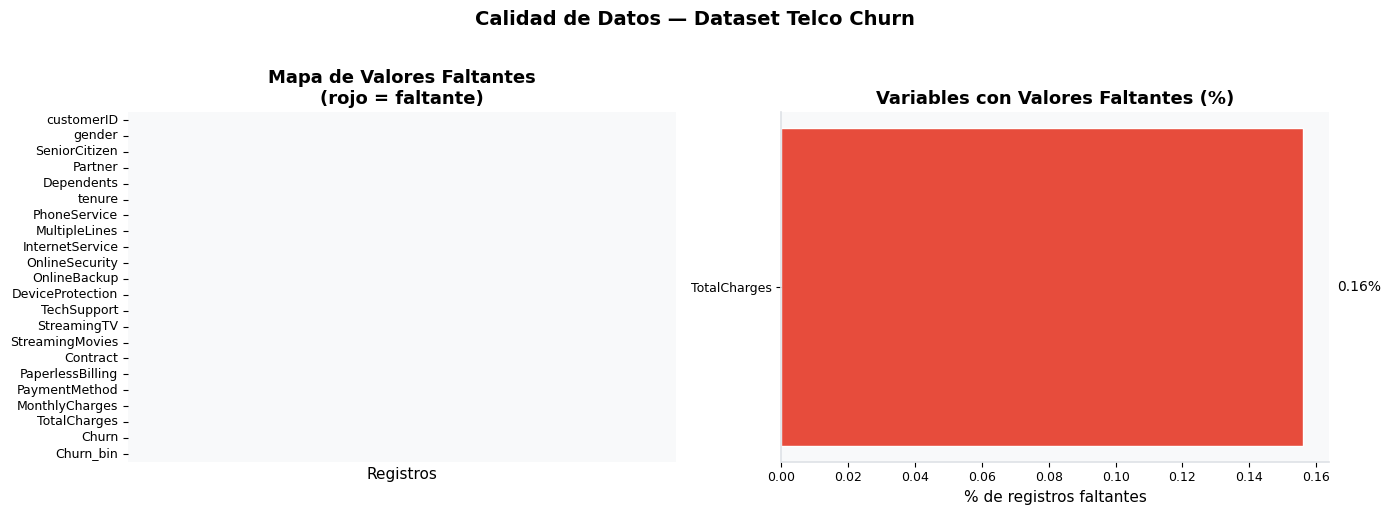

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: heatmap de nulos
missing = df.isnull().astype(int)
sns.heatmap(missing.T, ax=axes[0], cbar=False,
            cmap=['#F8F9FA', '#E74C3C'], yticklabels=True,
            xticklabels=False, linewidths=0)
axes[0].set_title('Mapa de Valores Faltantes\n(rojo = faltante)')
axes[0].set_xlabel('Registros')

# Panel 2: barras con % de nulos
pct_null = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
pct_null = pct_null[pct_null > 0]
if len(pct_null) > 0:
    axes[1].barh(pct_null.index, pct_null.values,
                 color=COLOR_YES, edgecolor='white')
    axes[1].set_title('Variables con Valores Faltantes (%)')
    axes[1].set_xlabel('% de registros faltantes')
    for i, v in enumerate(pct_null.values):
        axes[1].text(v + 0.01, i, f'{v:.2f}%', va='center')
else:
    axes[1].text(0.5, 0.5, 'Sin valores faltantes\n(excepto TotalCharges)',
                 ha='center', va='center', fontsize=12)
    axes[1].set_title('Valores Faltantes (%)')
    axes[1].axis('off')

plt.suptitle('Calidad de Datos — Dataset Telco Churn',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Interpretación:** `TotalCharges` presenta 11 valores faltantes (<0.2%) correspondientes a clientes sin historial de facturación (probablemente dados de alta recientemente). Se eliminan antes del modelado sin impacto estadístico relevante.

## 2. Análisis de la Variable Objetivo — Churn

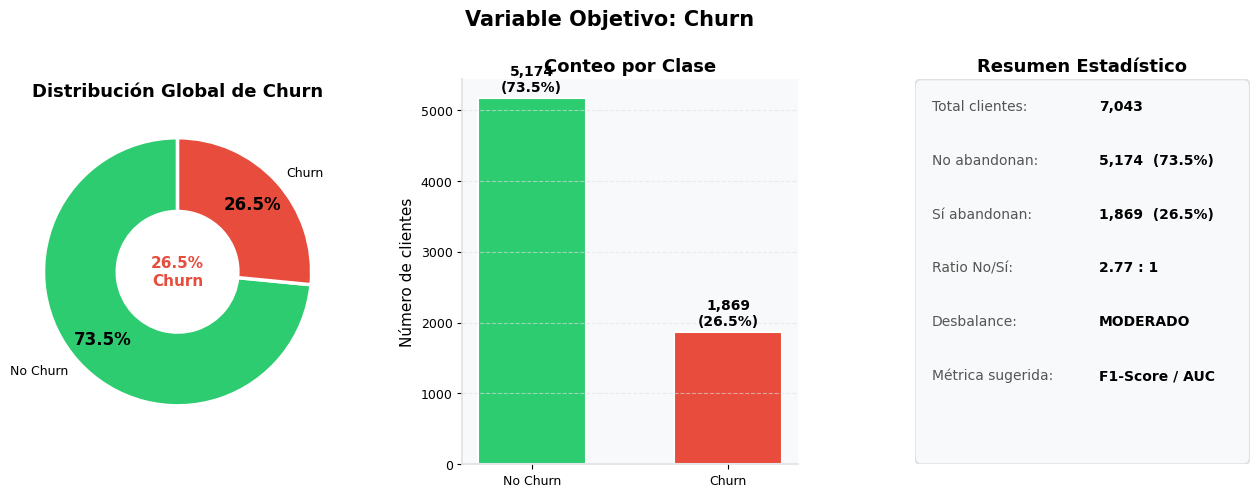

,Métrica,Valor
0,Total clientes,"7,043"
1,No abandonan,"5,174 (73.5%)"
2,Sí abandonan,"1,869 (26.5%)"
3,Ratio No/Sí,2.77 : 1
4,Desbalance,MODERADO
5,Métrica sugerida,F1-Score / AUC


In [45]:
churn_counts = df['Churn'].value_counts()
churn_pct    = df['Churn'].value_counts(normalize=True) * 100

fig = plt.figure(figsize=(16, 5))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

# ── Panel 1: Donut chart ─────────────────────────────────────
ax1 = fig.add_subplot(gs[0])
wedges, texts, autotexts = ax1.pie(
    churn_counts, labels=['No Churn', 'Churn'],
    colors=PALETTE, autopct='%1.1f%%',
    startangle=90, pctdistance=0.75,
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2.5))
for at in autotexts:
    at.set_fontsize(12); at.set_fontweight('bold')
ax1.set_title('Distribución Global de Churn')
centre = plt.Circle((0,0), 0.40, fc='white')
ax1.add_patch(centre)
ax1.text(0, 0, f'{churn_pct["Yes"]:.1f}%\nChurn',
         ha='center', va='center', fontsize=11, fontweight='bold', color=COLOR_YES)

# ── Panel 2: Barras con conteos ──────────────────────────────
ax2 = fig.add_subplot(gs[1])
bars = ax2.bar(['No Churn', 'Churn'], churn_counts,
               color=PALETTE, edgecolor='white', linewidth=1.5, width=0.55)
ax2.set_title('Conteo por Clase')
ax2.set_ylabel('Número de clientes')
ax2.grid(True, axis='y')
for bar, cnt, pct in zip(bars, churn_counts, churn_pct):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 50,
             f'{cnt:,}\n({pct:.1f}%)',
             ha='center', va='bottom', fontweight='bold', fontsize=10)

# ── Panel 3: Texto con métricas clave ───────────────────────
ax3 = fig.add_subplot(gs[2])
ax3.axis('off')
ratio = churn_counts['No'] / churn_counts['Yes']
metricas = [
    ('Total clientes',    f"{len(df):,}"),
    ('No abandonan',      f"{churn_counts['No']:,}  ({churn_pct['No']:.1f}%)"),
    ('Sí abandonan',      f"{churn_counts['Yes']:,}  ({churn_pct['Yes']:.1f}%)"),
    ('Ratio No/Sí',       f"{ratio:.2f} : 1"),
    ('Desbalance',        'MODERADO'),
    ('Métrica sugerida',  'F1-Score / AUC'),
]
y = 0.92
for label, val in metricas:
    ax3.text(0.05, y, label + ':', fontsize=10, color='#555', transform=ax3.transAxes)
    ax3.text(0.55, y, val,         fontsize=10, fontweight='bold', transform=ax3.transAxes)
    y -= 0.14
ax3.set_title('Resumen Estadístico')
ax3.add_patch(mpatches.FancyBboxPatch((0.02, 0.02), 0.96, 0.96,
    boxstyle='round,pad=0.02', linewidth=1.5,
    edgecolor='#DEE2E6', facecolor='#F8F9FA', transform=ax3.transAxes))

plt.suptitle('Variable Objetivo: Churn', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

metricas_df = pd.DataFrame(metricas, columns=['Métrica', 'Valor'])
display_table(metricas_df, caption='Resumen de métricas de Churn')


**Interpretación:** El dataset presenta un desbalance moderado de **73.5% / 26.5%**. Aunque no es extremo, un clasificador trivial que prediga siempre "No Churn" obtendría 73.5% de accuracy — lo que sería completamente engañoso. Por ello se priorizan F1-Score y AUC-ROC como métricas de evaluación.

## 3. Análisis de Variables Numéricas

### 3.1 Estadísticas descriptivas

In [46]:
desc = df[num_cols].describe().T
desc['CV (%)'] = (desc['std'] / desc['mean'] * 100).round(1)
desc['skew']   = df[num_cols].skew().round(3)
desc['kurt']   = df[num_cols].kurt().round(3)

display_table(desc.round(2), caption='Estadísticas descriptivas extendidas')


,count,mean,std,min,25%,50%,75%,max,CV (%),skew,kurt
tenure,7043.000000,32.370000,24.560000,0.000000,9.000000,29.000000,55.000000,72.000000,75.900000,0.240000,-1.390000
MonthlyCharges,7043.000000,64.760000,30.090000,18.250000,35.500000,70.350000,89.850000,118.750000,46.500000,-0.220000,-1.260000
TotalCharges,7032.000000,2283.300000,2266.770000,18.800000,401.450000,1397.480000,3794.740000,8684.800000,99.300000,0.960000,-0.230000


### 3.2 Distribuciones con KDE — comparación Churn vs No Churn

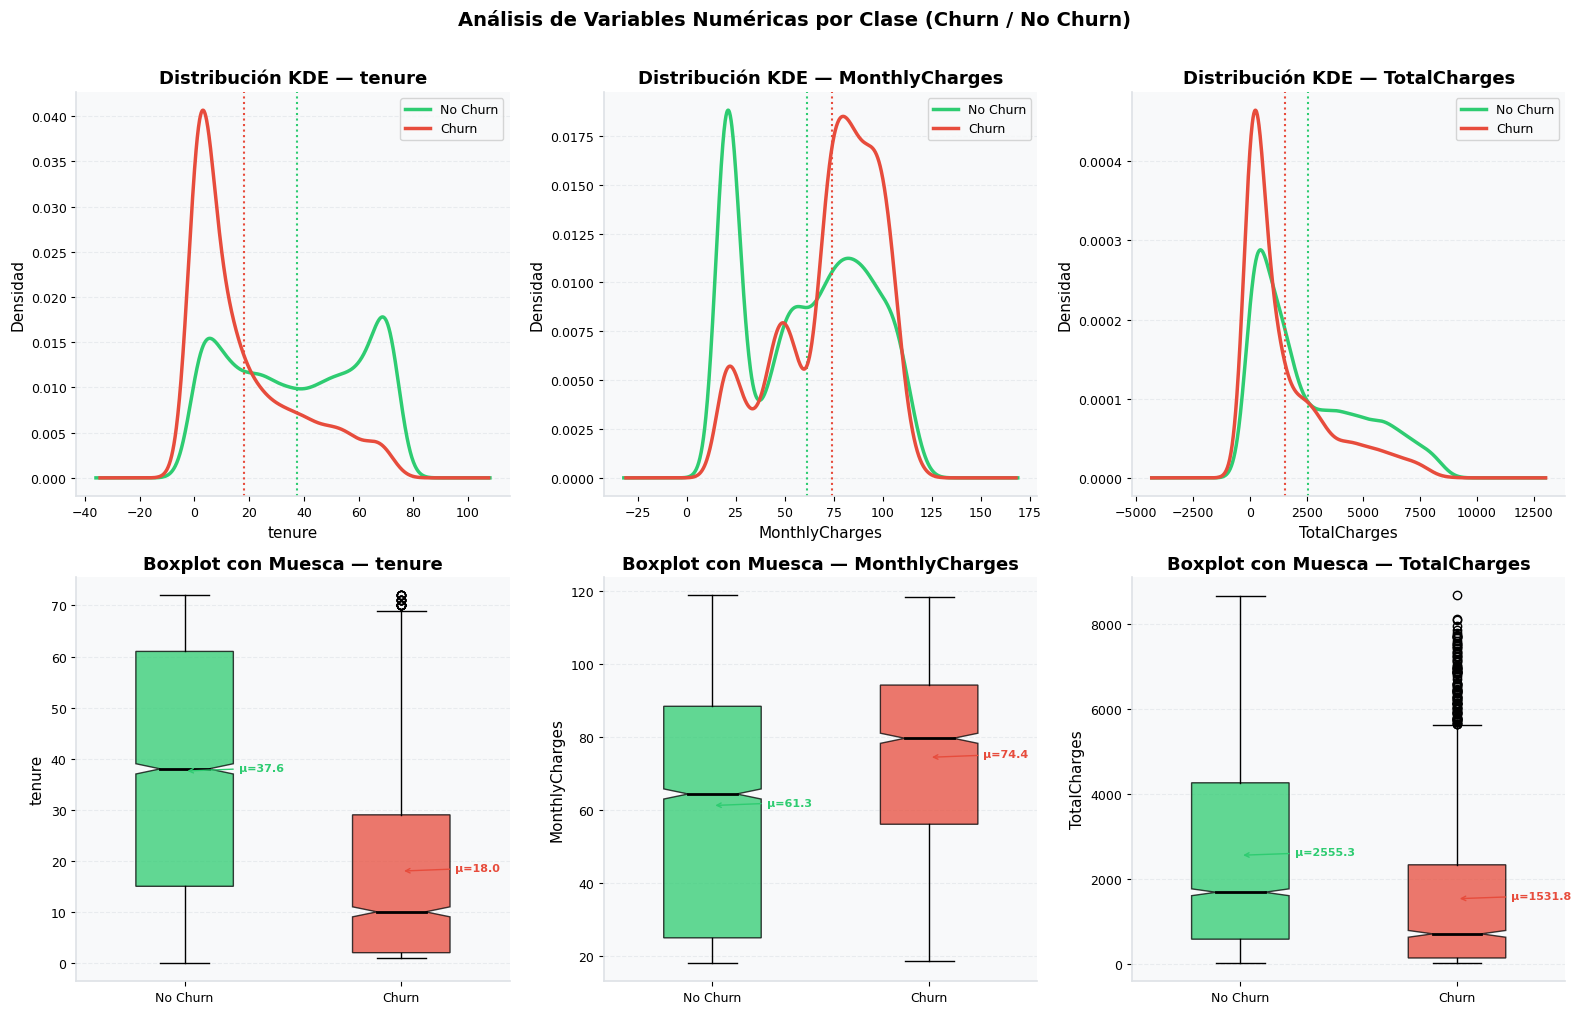

In [47]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for col_idx, col in enumerate(num_cols):
    # ── Fila 1: KDE por clase ────────────────────────────────
    ax = axes[0, col_idx]
    for churn_val, color, label in [('No', COLOR_NO, 'No Churn'),
                                     ('Yes', COLOR_YES, 'Churn')]:
        subset = df[df['Churn'] == churn_val][col].dropna()
        subset.plot.kde(ax=ax, color=color, lw=2.5, label=label)
        ax.axvline(subset.mean(), color=color, linestyle=':', lw=1.5)
    ax.set_title(f'Distribución KDE — {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Densidad')
    ax.legend(fontsize=9)
    ax.grid(True, axis='y')

    # ── Fila 2: Boxplot por clase ────────────────────────────
    ax2 = axes[1, col_idx]
    data_plot = [df[df['Churn'] == v][col].dropna() for v in ['No', 'Yes']]
    bp = ax2.boxplot(data_plot, patch_artist=True, notch=True,
                     widths=0.45, labels=['No Churn', 'Churn'])
    for patch, color in zip(bp['boxes'], PALETTE):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)
    for median in bp['medians']:
        median.set_color('black'); median.set_linewidth(2)
    ax2.set_title(f'Boxplot con Muesca — {col}')
    ax2.set_ylabel(col)
    ax2.grid(True, axis='y')

    # Anotación de medias
    for i, (vals, color) in enumerate(zip(data_plot, PALETTE), 1):
        ax2.annotate(f'μ={vals.mean():.1f}',
                     xy=(i, vals.mean()), xytext=(i+0.25, vals.mean()),
                     fontsize=8, color=color, fontweight='bold',
                     arrowprops=dict(arrowstyle='->', color=color, lw=1))

plt.suptitle('Análisis de Variables Numéricas por Clase (Churn / No Churn)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Interpretación:**
- **Tenure:** Clientes que abandonan tienen mediana de antigüedad mucho menor (~10 meses) vs. los que permanecen (~37 meses). La distribución de churn está sesgada a la derecha — los primeros meses son el período crítico de riesgo.
- **MonthlyCharges:** Los clientes con churn pagan significativamente más al mes (~$74) vs. los que permanecen (~$61). Cargos altos correlacionan con insatisfacción.
- **TotalCharges:** Los que abandonan tienen menores cargos totales, coherente con su menor antigüedad. Las muescas en los boxplots confirman diferencias estadísticamente significativas entre medianas.

### 3.3 Matriz de correlación y pairplot

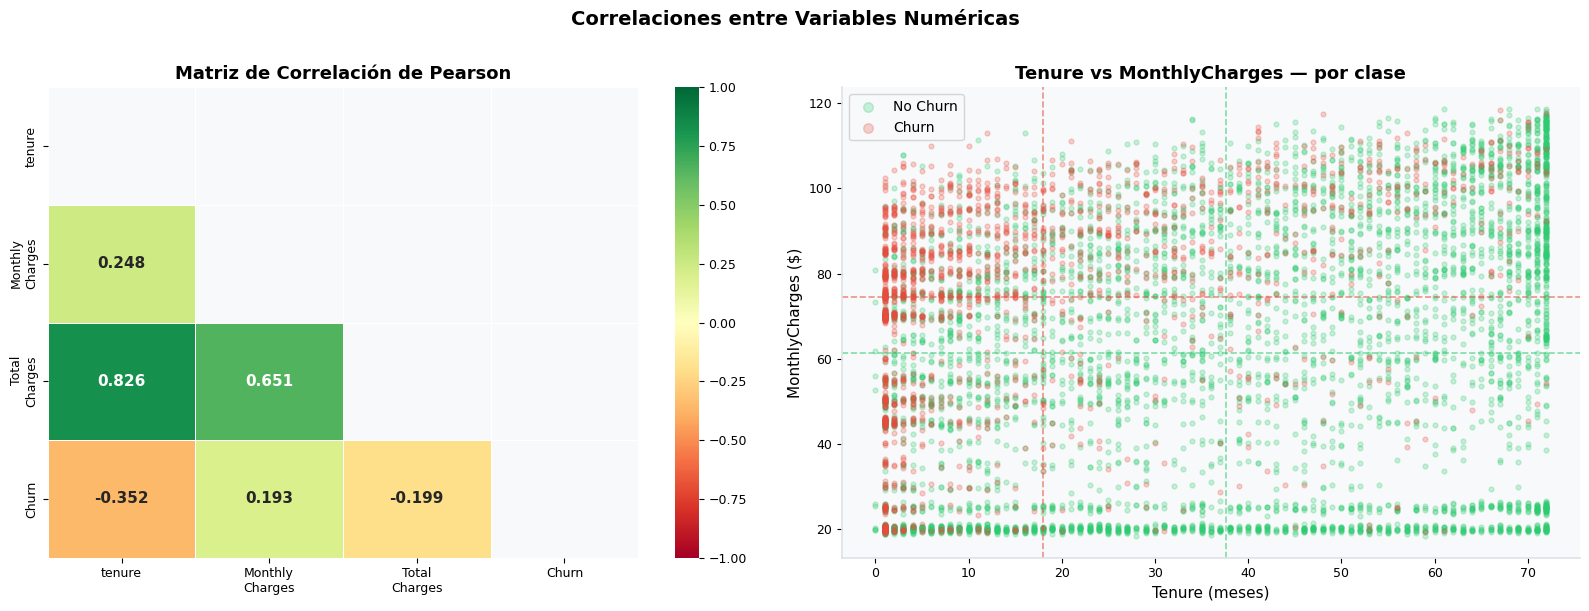

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Panel 1: Heatmap de correlación ─────────────────────────
corr_data = df[num_cols + ['Churn_bin']].corr()
mask = np.triu(np.ones_like(corr_data, dtype=bool))
sns.heatmap(corr_data, ax=axes[0], annot=True, fmt='.3f',
            cmap='RdYlGn', center=0, mask=mask,
            linewidths=0.5, linecolor='white',
            annot_kws={'size': 11, 'weight': 'bold'},
            vmin=-1, vmax=1,
            xticklabels=['tenure', 'Monthly\nCharges', 'Total\nCharges', 'Churn'],
            yticklabels=['tenure', 'Monthly\nCharges', 'Total\nCharges', 'Churn'])
axes[0].set_title('Matriz de Correlación de Pearson')

# ── Panel 2: Scatter tenure vs MonthlyCharges ────────────────
for churn_val, color, label in [('No', COLOR_NO, 'No Churn'),
                                  ('Yes', COLOR_YES, 'Churn')]:
    sub = df[df['Churn'] == churn_val]
    axes[1].scatter(sub['tenure'], sub['MonthlyCharges'],
                    c=color, alpha=0.25, s=12, label=label, rasterized=True)
axes[1].set_xlabel('Tenure (meses)')
axes[1].set_ylabel('MonthlyCharges ($)')
axes[1].set_title('Tenure vs MonthlyCharges — por clase')
axes[1].legend(markerscale=2)

# Líneas de media
for col_x, col_y, churn_val, color in [
    ('tenure','MonthlyCharges','No',  COLOR_NO),
    ('tenure','MonthlyCharges','Yes', COLOR_YES)]:
    sub = df[df['Churn'] == churn_val]
    axes[1].axvline(sub[col_x].mean(), color=color, linestyle='--', lw=1.2, alpha=0.6)
    axes[1].axhline(sub[col_y].mean(), color=color, linestyle='--', lw=1.2, alpha=0.6)

plt.suptitle('Correlaciones entre Variables Numéricas',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Interpretación:** `TotalCharges` tiene alta correlación con `tenure` (0.83) — es una variable derivada (tenure × precio). La correlación de `tenure` con `Churn_bin` es negativa (-0.35): a mayor antigüedad, menor probabilidad de churn. El scatter revela una zona de alto riesgo en la esquina superior izquierda: clientes nuevos con cargos altos.

### 3.4 Detección de outliers — Método IQR

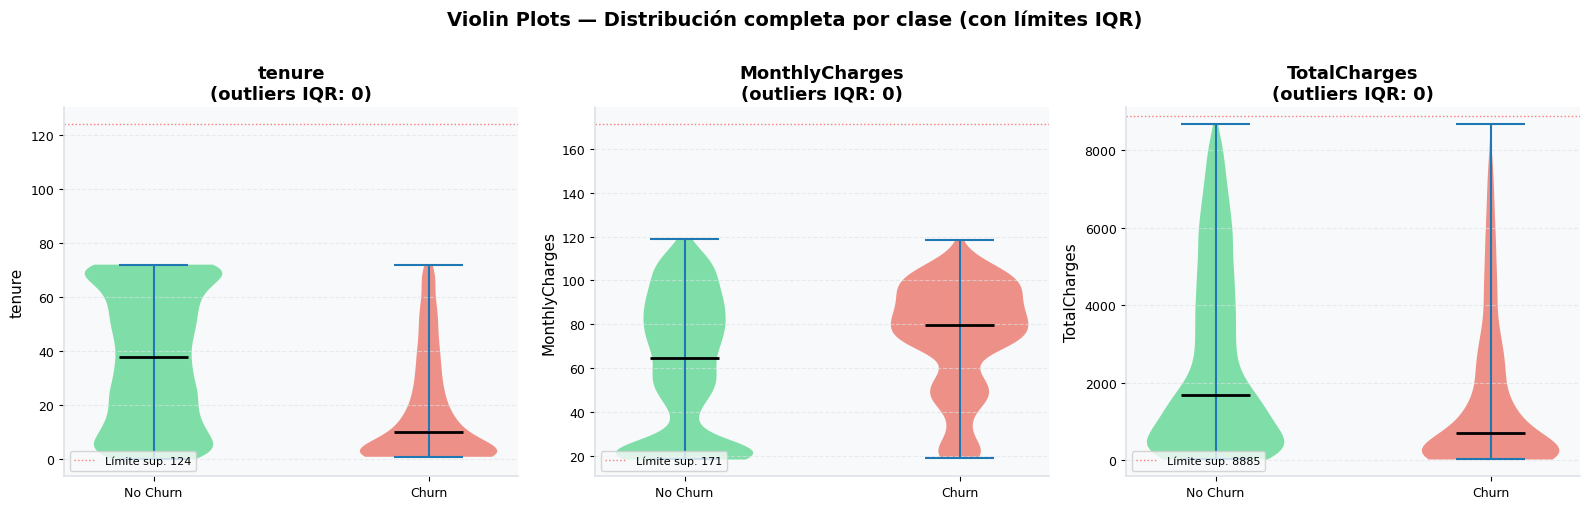

,Q1,Q3,IQR,Lower,Upper,N_outliers
tenure,9.000000,55.000000,46.000000,-60.000000,124.000000,0.000000
MonthlyCharges,35.500000,89.850000,54.350000,-46.020000,171.380000,0.000000
TotalCharges,401.450000,3794.740000,3393.290000,-4688.480000,8884.670000,0.000000


In [49]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

outlier_report = {}
for i, col in enumerate(num_cols):
    data = df[col].dropna()
    Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
    IQR    = Q3 - Q1
    lower  = Q1 - 1.5 * IQR
    upper  = Q3 + 1.5 * IQR
    n_out  = ((data < lower) | (data > upper)).sum()
    outlier_report[col] = {'Q1': Q1, 'Q3': Q3, 'IQR': IQR,
                            'Lower': lower, 'Upper': upper, 'N_outliers': n_out}

    # Violin + strip
    parts = axes[i].violinplot([df[df['Churn']=='No'][col].dropna(),
                                 df[df['Churn']=='Yes'][col].dropna()],
                                positions=[1,2], showmedians=True,
                                showextrema=True)
    for pc, color in zip(parts['bodies'], PALETTE):
        pc.set_facecolor(color); pc.set_alpha(0.6)
    parts['cmedians'].set_color('black'); parts['cmedians'].set_linewidth(2)

    axes[i].set_xticks([1, 2])
    axes[i].set_xticklabels(['No Churn', 'Churn'])
    axes[i].set_title(f'{col}\n(outliers IQR: {n_out})')
    axes[i].set_ylabel(col)
    axes[i].grid(True, axis='y')
    axes[i].axhline(upper, color='red', linestyle=':', lw=1, alpha=0.5,
                    label=f'Límite sup. {upper:.0f}')
    axes[i].legend(fontsize=8)

plt.suptitle('Violin Plots — Distribución completa por clase (con límites IQR)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

outlier_df = pd.DataFrame(outlier_report).T.round(2)
display_table(outlier_df, caption='Reporte de outliers por variable')


**Interpretación:** Los violin plots revelan la forma completa de la distribución, no solo los cuartiles. `MonthlyCharges` presenta distribución bimodal en ambas clases — sugiere dos perfiles de cliente diferenciados (servicios básicos vs. premium). Los outliers detectados son genuinos (clientes reales con comportamiento extremo) y no errores de captura.

## 4. Análisis de Variables Categóricas

### 4.1 Tasa de Churn por variable binaria

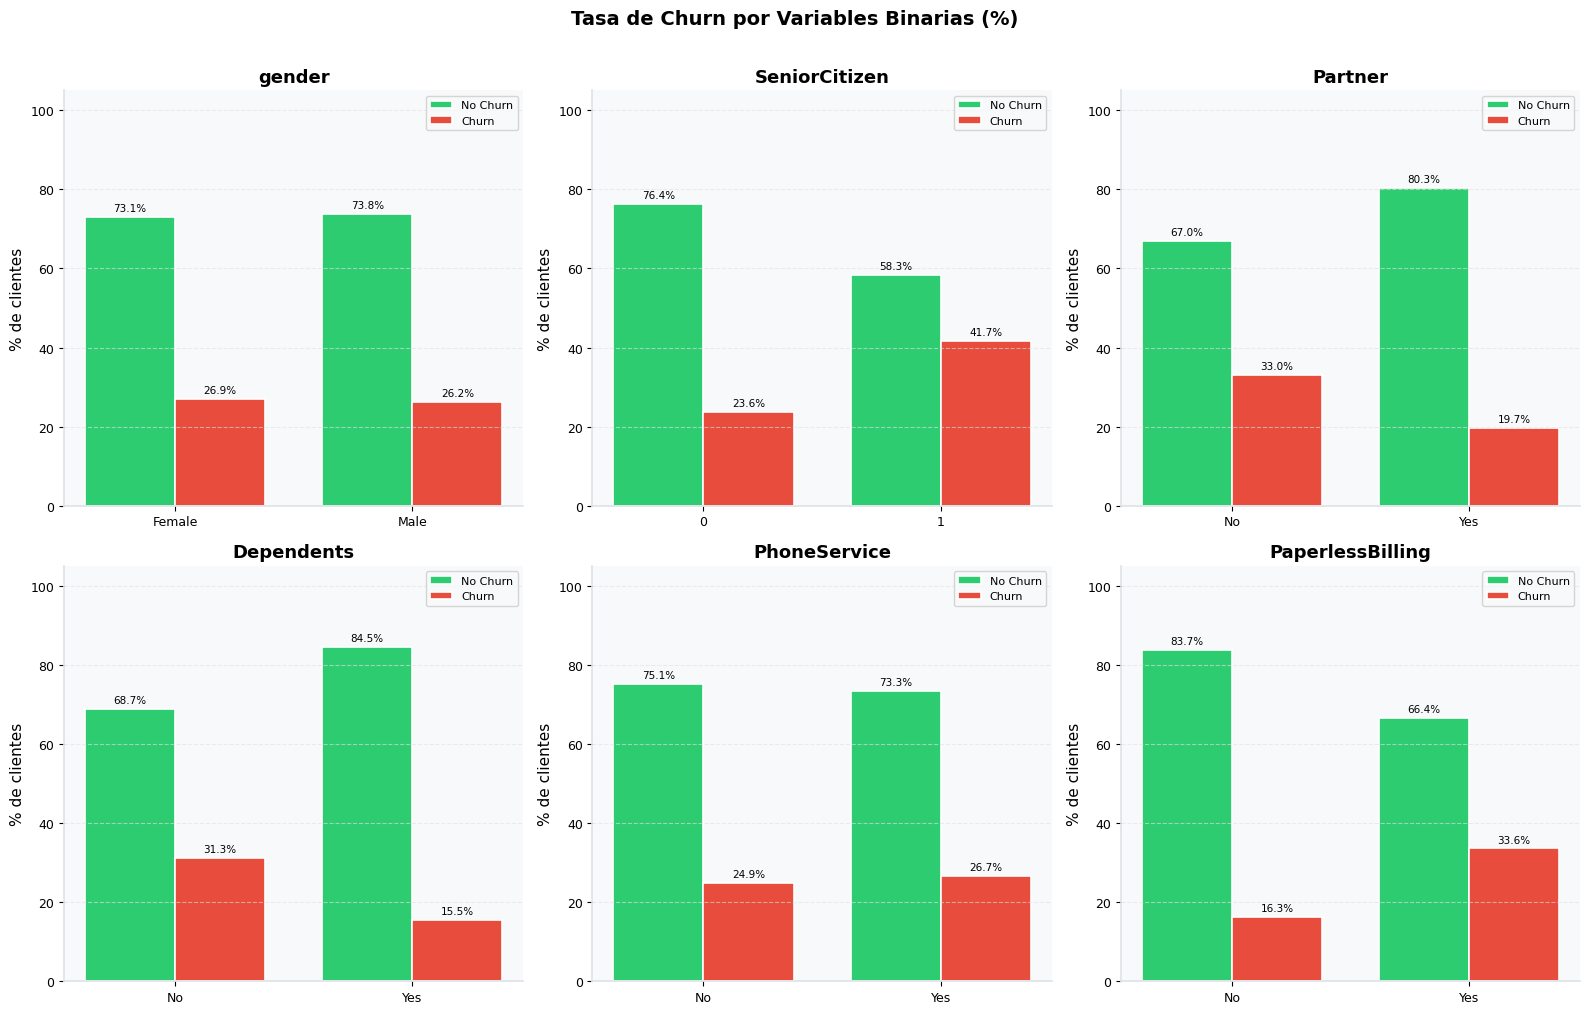

In [50]:
bin_vars = ['gender', 'SeniorCitizen', 'Partner',
            'Dependents', 'PhoneService', 'PaperlessBilling']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(bin_vars):
    ct = pd.crosstab(df[col], df['Churn'], normalize='index') * 100
    ct = ct.reindex(columns=['No', 'Yes'])

    x   = np.arange(len(ct))
    w   = 0.38
    ax  = axes[i]
    b1  = ax.bar(x - w/2, ct['No'],  w, color=COLOR_NO,  label='No Churn',
                 edgecolor='white', linewidth=1.2)
    b2  = ax.bar(x + w/2, ct['Yes'], w, color=COLOR_YES, label='Churn',
                 edgecolor='white', linewidth=1.2)

    ax.set_xticks(x)
    ax.set_xticklabels(ct.index, fontsize=9)
    ax.set_ylabel('% de clientes')
    ax.set_ylim(0, 105)
    ax.set_title(f'{col}')
    ax.legend(fontsize=8)
    ax.grid(True, axis='y')

    for bar in list(b1) + list(b2):
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 1,
                f'{h:.1f}%', ha='center', va='bottom', fontsize=7.5)

plt.suptitle('Tasa de Churn por Variables Binarias (%)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


- **SeniorCitizen:** Los adultos mayores tienen tasa de churn del ~42% vs. ~24% en el resto — casi el doble. Segmento de altísima prioridad.
- **Partner / Dependents:** Clientes sin pareja ni dependientes presentan mayor tasa de churn. La responsabilidad familiar actúa como factor de retención.
- **PaperlessBilling:** El 34% de quienes usan facturación electrónica abandonan vs. 16% de los que no — posiblemente por perfil de cliente más digital y comparativo.

### 4.2 Tasa de Churn por variables de servicio

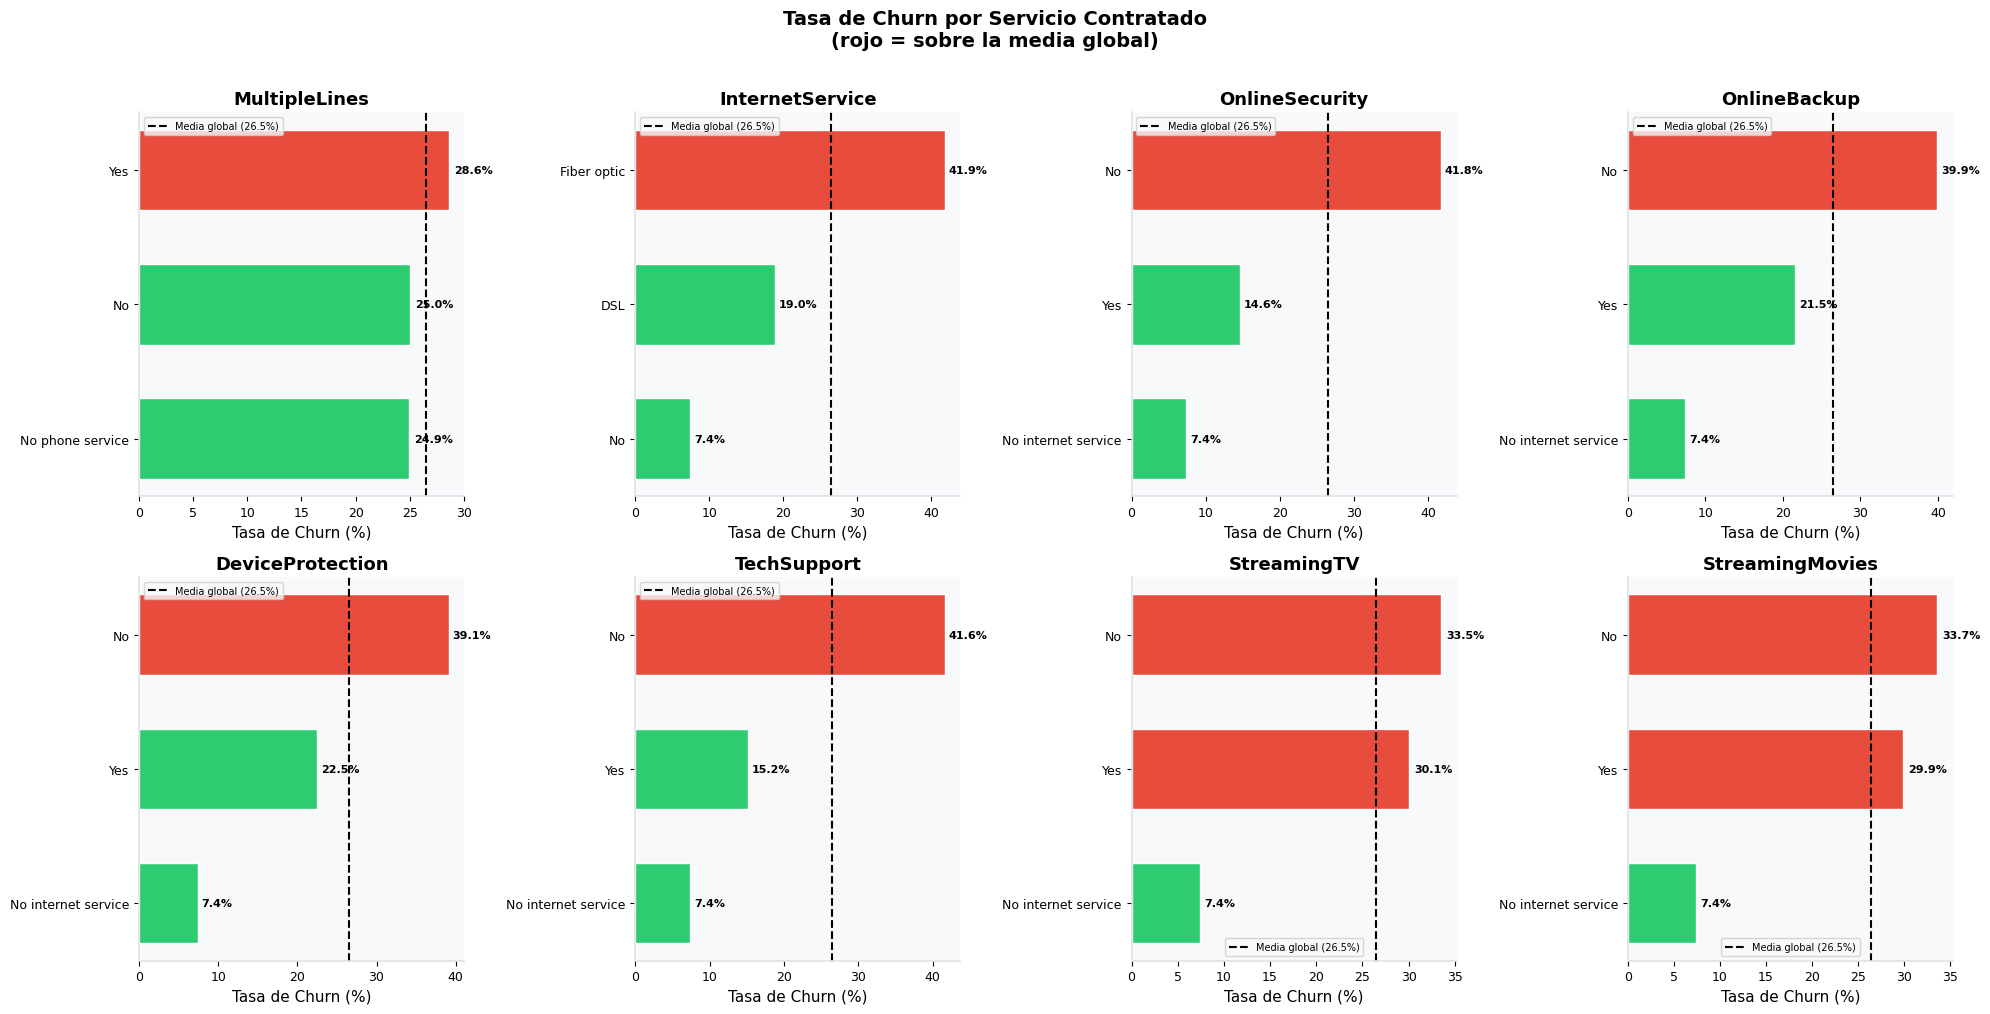

In [51]:
service_vars = ['MultipleLines', 'InternetService', 'OnlineSecurity',
                'OnlineBackup', 'DeviceProtection', 'TechSupport',
                'StreamingTV', 'StreamingMovies']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(service_vars):
    ct = (pd.crosstab(df[col], df['Churn'], normalize='index') * 100)
    ct = ct.reindex(columns=['No', 'Yes'])

    churn_rates = ct['Yes'].sort_values(ascending=True)
    bars = axes[i].barh(churn_rates.index, churn_rates.values,
                        color=[COLOR_YES if v > 26.5 else COLOR_NO
                               for v in churn_rates.values],
                        edgecolor='white', height=0.6)
    axes[i].axvline(26.5, color='black', linestyle='--', lw=1.5,
                    label=f'Media global (26.5%)')
    axes[i].set_title(col)
    axes[i].set_xlabel('Tasa de Churn (%)')
    axes[i].legend(fontsize=7)
    for bar, val in zip(bars, churn_rates.values):
        axes[i].text(val + 0.5, bar.get_y() + bar.get_height()/2,
                     f'{val:.1f}%', va='center', fontsize=8, fontweight='bold')

plt.suptitle('Tasa de Churn por Servicio Contratado\n(rojo = sobre la media global)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

- **InternetService — Fiber optic:** Tasa de churn del ~42%. Es el predictor más potente entre los servicios. Los clientes de fibra óptica son más propensos a comparar precios y cambiar de proveedor.
- **OnlineSecurity / TechSupport:** Clientes *sin* estos servicios tienen tasas de churn 2–3× más altas. Ofrecerlos como add-on gratuito podría ser una intervención de retención de bajo costo.
- **Streaming TV / Movies:** Tasas similares entre sí (~30%), sugieren que el contenido de entretenimiento no retiene por sí solo.

### 4.3 Contrato y Método de pago — variables de alto impacto

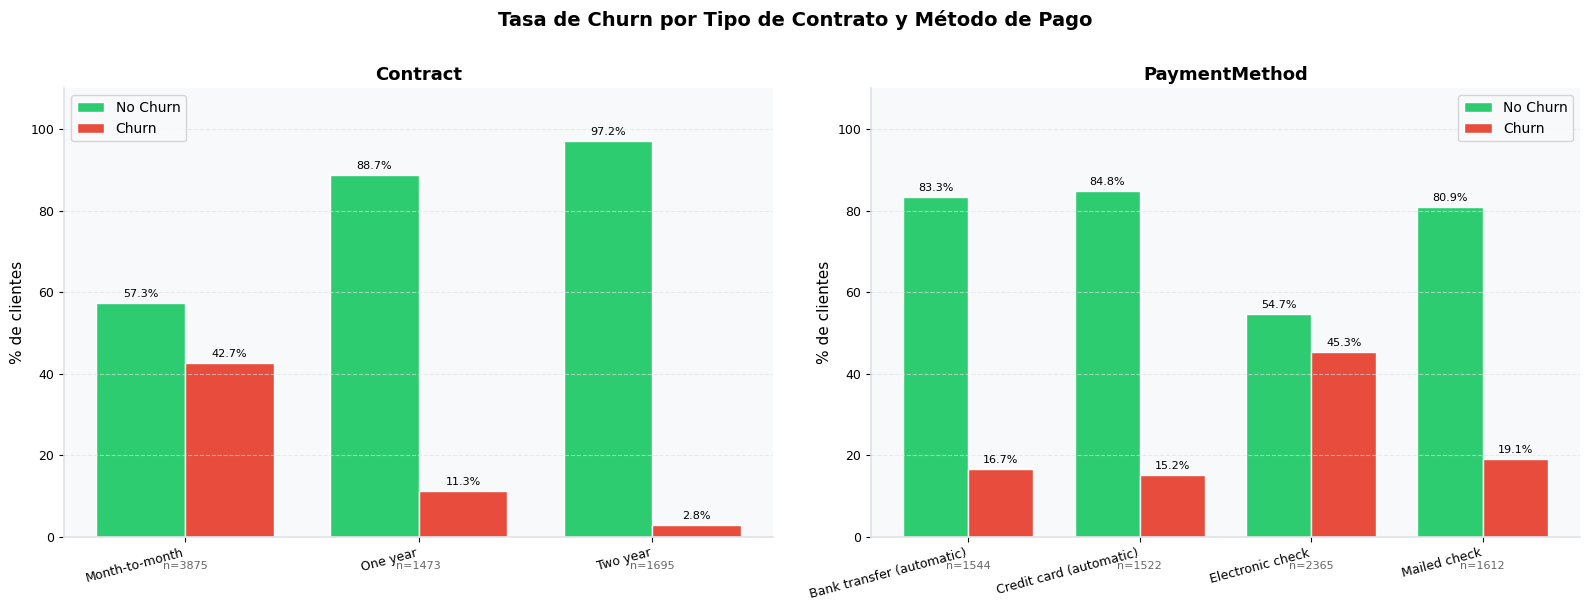

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, col in zip(axes, ['Contract', 'PaymentMethod']):
    ct = pd.crosstab(df[col], df['Churn'])
    ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

    x = np.arange(len(ct_pct))
    w = 0.38
    b1 = ax.bar(x - w/2, ct_pct['No'],  w, color=COLOR_NO,
                label='No Churn', edgecolor='white')
    b2 = ax.bar(x + w/2, ct_pct['Yes'], w, color=COLOR_YES,
                label='Churn',    edgecolor='white')
    ax.set_xticks(x)
    ax.set_xticklabels(ct_pct.index, rotation=15, ha='right', fontsize=9)
    ax.set_ylabel('% de clientes')
    ax.set_ylim(0, 110)
    ax.set_title(col)
    ax.legend()
    ax.grid(True, axis='y')

    for bar in list(b1) + list(b2):
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 1,
                f'{h:.1f}%', ha='center', va='bottom', fontsize=8)

    # Añadir conteos absolutos
    for j, (idx, row) in enumerate(ct.iterrows()):
        ax.text(j, -8, f'n={row.sum()}', ha='center',
                fontsize=8, color='#666', transform=ax.transData)

plt.suptitle('Tasa de Churn por Tipo de Contrato y Método de Pago',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Interpretación:**
- **Contract:** El hallazgo más contundente del EDA. Contratos mes a mes tienen **43% de churn** vs. 11% (1 año) y 3% (2 años). El tipo de contrato es la variable con mayor poder discriminatorio del dataset.
- **PaymentMethod:** El pago con *Electronic check* tiene el doble de churn (~45%) respecto a los otros métodos (~15–18%). Este comportamiento puede indicar clientes con menor compromiso o satisfacción con el servicio.

## 5. Análisis Bivariado Profundo

### 5.1 Tenure segmentado en cohortes

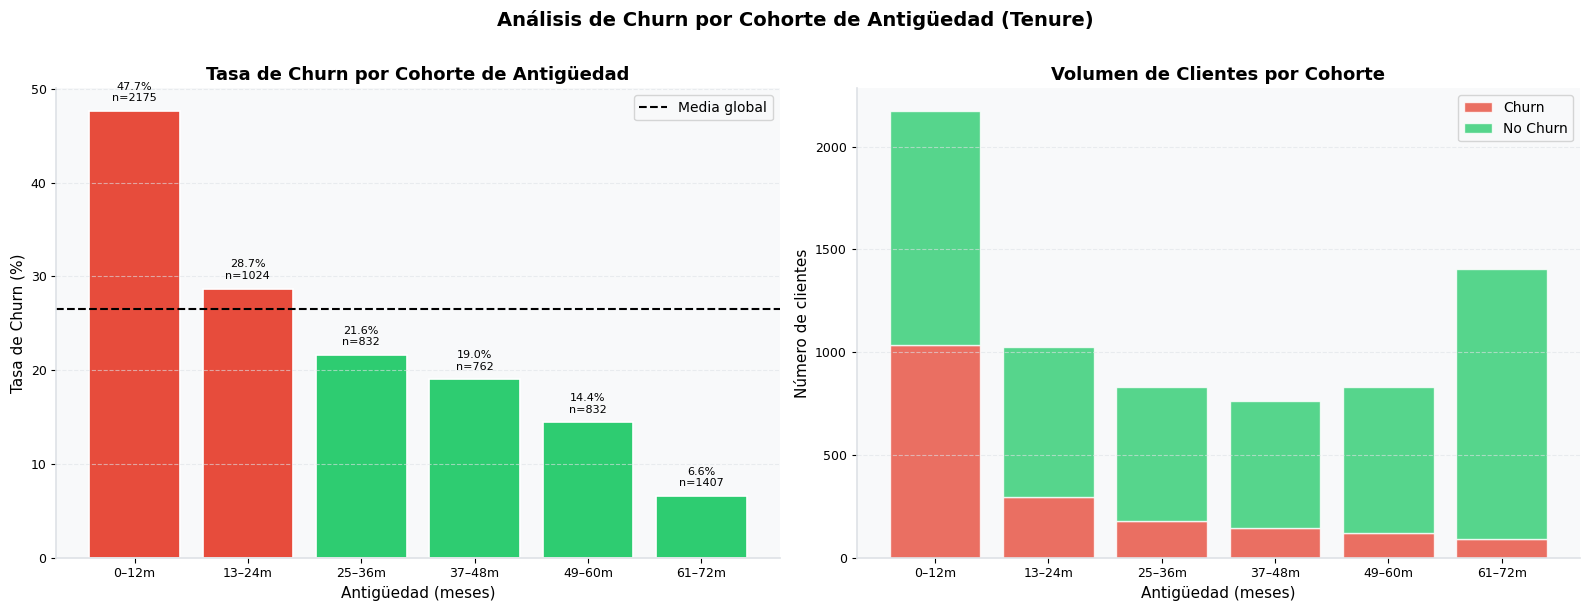

,Cohorte,Tasa_Churn,N_Churn,Total,Tasa_Churn_pct
0,0–12m,0.476782,1037,2175,47.678161
1,13–24m,0.287109,294,1024,28.710938
2,25–36m,0.216346,180,832,21.634615
3,37–48m,0.190289,145,762,19.028871
4,49–60m,0.144231,120,832,14.423077
5,61–72m,0.066098,93,1407,6.609808


In [53]:
# Crear cohortes de antigüedad
bins   = [0, 12, 24, 36, 48, 60, 72]
labels = ['0–12m', '13–24m', '25–36m', '37–48m', '49–60m', '61–72m']
df['tenure_group'] = pd.cut(df['tenure'], bins=bins, labels=labels, right=True)

churn_by_tenure = df.groupby('tenure_group', observed=True)['Churn_bin'].agg(
    ['mean', 'sum', 'count']).reset_index()
churn_by_tenure.columns = ['Cohorte', 'Tasa_Churn', 'N_Churn', 'Total']
churn_by_tenure['Tasa_Churn_pct'] = churn_by_tenure['Tasa_Churn'] * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel 1: Tasa de churn por cohorte
colors_bar = [COLOR_YES if v > 26.5 else COLOR_NO
              for v in churn_by_tenure['Tasa_Churn_pct']]
bars = axes[0].bar(churn_by_tenure['Cohorte'],
                   churn_by_tenure['Tasa_Churn_pct'],
                   color=colors_bar, edgecolor='white', linewidth=1.2)
axes[0].axhline(26.5, color='black', linestyle='--', lw=1.5, label='Media global')
axes[0].set_title('Tasa de Churn por Cohorte de Antigüedad')
axes[0].set_ylabel('Tasa de Churn (%)')
axes[0].set_xlabel('Antigüedad (meses)')
axes[0].legend()
axes[0].grid(True, axis='y')
for bar, row in zip(bars, churn_by_tenure.itertuples()):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
                 f'{row.Tasa_Churn_pct:.1f}%\nn={row.Total}',
                 ha='center', va='bottom', fontsize=8)

# Panel 2: Stacked area — acumulado de churn
axes[1].bar(churn_by_tenure['Cohorte'],
            churn_by_tenure['N_Churn'],
            color=COLOR_YES, alpha=0.8, label='Churn', edgecolor='white')
axes[1].bar(churn_by_tenure['Cohorte'],
            churn_by_tenure['Total'] - churn_by_tenure['N_Churn'],
            bottom=churn_by_tenure['N_Churn'],
            color=COLOR_NO, alpha=0.8, label='No Churn', edgecolor='white')
axes[1].set_title('Volumen de Clientes por Cohorte')
axes[1].set_ylabel('Número de clientes')
axes[1].set_xlabel('Antigüedad (meses)')
axes[1].legend()
axes[1].grid(True, axis='y')

plt.suptitle('Análisis de Churn por Cohorte de Antigüedad (Tenure)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

display_table(churn_by_tenure, caption='Churn por cohorte de tenure')


**Interpretación:** El patrón es inequívoco: la tasa de churn cae drásticamente con la antigüedad. Los primeros 12 meses concentran el **47.4% de churn** — casi la mitad de los abandonos ocurren en el primer año. Después de 24 meses la tasa se estabiliza por debajo del 20%. Este hallazgo tiene implicaciones directas para diseñar programas de retención focalizados en clientes nuevos.

### 5.2 Mapa de calor de Churn — Tenure × MonthlyCharges

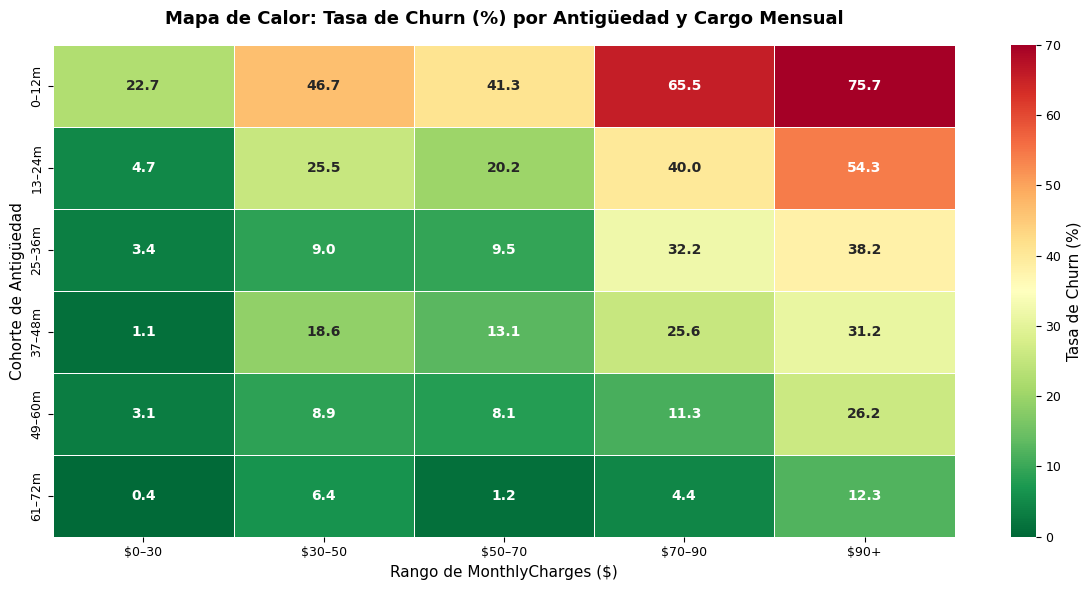

In [54]:
df['charge_group'] = pd.cut(df['MonthlyCharges'],
                           bins=[0,30,50,70,90,120],
                           labels=['$0–30','$30–50','$50–70','$70–90','$90+'])

pivot = df.groupby(['tenure_group','charge_group'], observed=True)['Churn_bin'].mean().unstack() * 100

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(pivot, ax=ax, annot=True, fmt='.1f', cmap='RdYlGn_r',
            linewidths=0.5, linecolor='white',
            annot_kws={'size': 10, 'weight': 'bold'},
            vmin=0, vmax=70,
            cbar_kws={'label': 'Tasa de Churn (%)'})
ax.set_title('Mapa de Calor: Tasa de Churn (%) por Antigüedad y Cargo Mensual',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Rango de MonthlyCharges ($)')
ax.set_ylabel('Cohorte de Antigüedad')
plt.tight_layout()
plt.show()

**Interpretación:** El cuadrante superior izquierdo (clientes nuevos + altos cargos) concentra las tasas de churn más extremas, superando el 60–70% en algunos segmentos. Representa el perfil de mayor riesgo: clientes que contrataron servicios premium pero aún no tienen suficiente historial de satisfacción para comprometerse a largo plazo.

### 5.3 Análisis de Chi-cuadrado — Asociación con Churn

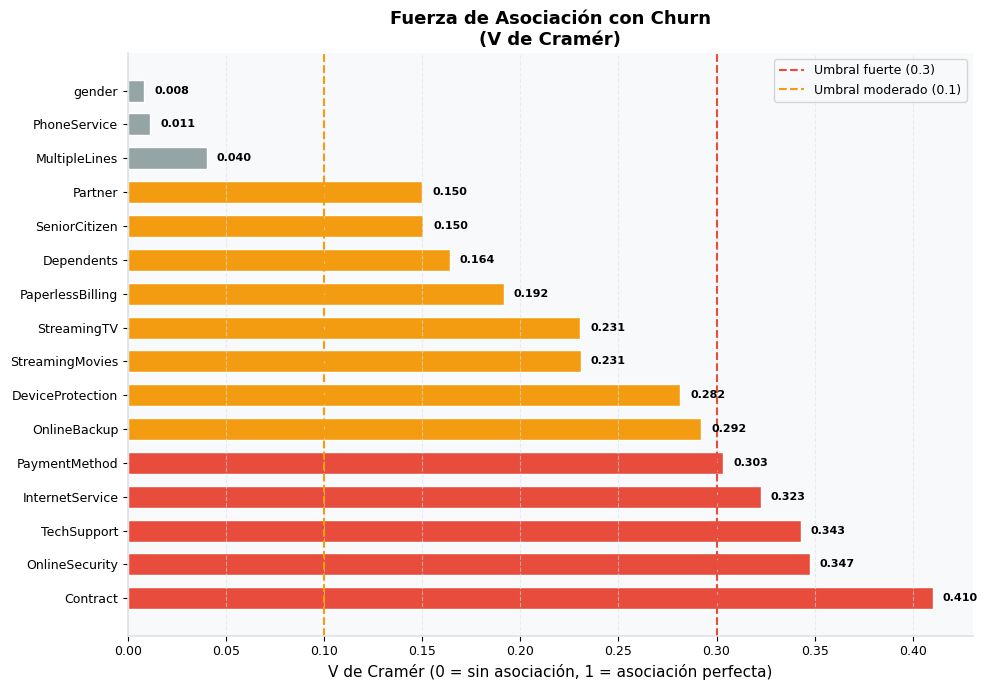

,Variable,Chi2,p-value,Cramér V,Asociación,Sig (α=0.05)
0,Contract,1184.600000,0.000000,0.410100,Fuerte,✅
1,OnlineSecurity,850.000000,0.000000,0.347400,Fuerte,✅
2,TechSupport,828.200000,0.000000,0.342900,Fuerte,✅
3,InternetService,732.310000,0.000000,0.322500,Fuerte,✅
4,PaymentMethod,648.140000,0.000000,0.303400,Fuerte,✅
5,OnlineBackup,601.810000,0.000000,0.292300,Moderada,✅
6,DeviceProtection,558.420000,0.000000,0.281600,Moderada,✅
7,StreamingMovies,375.660000,0.000000,0.231000,Moderada,✅
8,StreamingTV,374.200000,0.000000,0.230500,Moderada,✅
9,PaperlessBilling,258.280000,0.000000,0.191500,Moderada,✅


In [55]:
from scipy.stats import chi2_contingency

chi2_results = []
all_cat = bin_vars + cat_cols

for col in all_cat:
    ct = pd.crosstab(df[col], df['Churn'])
    chi2, p, dof, _ = chi2_contingency(ct)
    n = ct.values.sum()
    v_cramer = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))
    chi2_results.append({
        'Variable':    col,
        'Chi2':        round(chi2, 2),
        'p-value':     p,
        'Cramér V':    round(v_cramer, 4),
        'Asociación':  'Fuerte' if v_cramer > 0.3 else
                       ('Moderada' if v_cramer > 0.1 else 'Débil'),
        'Sig (α=0.05)': '✅' if p < 0.05 else '❌'
    })

chi2_df = pd.DataFrame(chi2_results).sort_values('Cramér V', ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#E74C3C' if v > 0.3 else '#F39C12' if v > 0.1 else '#95A5A6'
          for v in chi2_df['Cramér V']]
bars = ax.barh(chi2_df['Variable'], chi2_df['Cramér V'],
               color=colors, edgecolor='white', height=0.65)
ax.axvline(0.3, color='#E74C3C', linestyle='--', lw=1.5, label='Umbral fuerte (0.3)')
ax.axvline(0.1, color='#F39C12', linestyle='--', lw=1.5, label='Umbral moderado (0.1)')
ax.set_title('Fuerza de Asociación con Churn\n(V de Cramér)', fontweight='bold')
ax.set_xlabel("V de Cramér (0 = sin asociación, 1 = asociación perfecta)")
ax.legend(fontsize=9)
ax.grid(True, axis='x')
for bar, val in zip(bars, chi2_df['Cramér V']):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()

# Mostrar la tabla completa en estilo de tabla
chi2_df = chi2_df.reset_index(drop=True)
display_table(chi2_df, caption='Tabla completa de asociaciones')


**Interpretación:** La V de Cramér cuantifica la fuerza de asociación entre cada variable categórica y el Churn (todas son estadísticamente significativas con p < 0.05). **Contract** lidera con V > 0.4 (asociación fuerte), seguido de **InternetService** y **OnlineSecurity**. Todas las variables tienen asociación significativa con el target, lo que valida el poder predictivo del dataset.

## 6. Perfil del Cliente en Riesgo

### 6.1 Radar chart — Comparación Churn vs No Churn

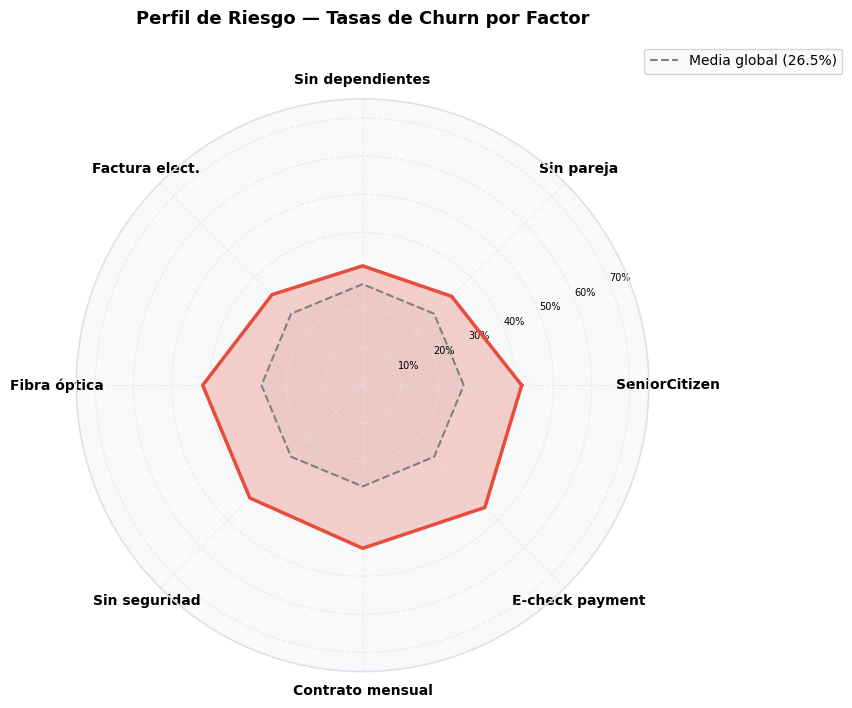

In [56]:
# Calcular tasas de churn para radar
radar_features = {
    'SeniorCitizen':     df.groupby('SeniorCitizen')['Churn_bin'].mean()[1],
    'Sin pareja':        df[df['Partner']=='No']['Churn_bin'].mean(),
    'Sin dependientes':  df[df['Dependents']=='No']['Churn_bin'].mean(),
    'Factura elect.':    df[df['PaperlessBilling']=='Yes']['Churn_bin'].mean(),
    'Fibra óptica':      df[df['InternetService']=='Fiber optic']['Churn_bin'].mean(),
    'Sin seguridad':     df[df['OnlineSecurity']=='No']['Churn_bin'].mean(),
    'Contrato mensual':  df[df['Contract']=='Month-to-month']['Churn_bin'].mean(),
    'E-check payment':   df[df['PaymentMethod']=='Electronic check']['Churn_bin'].mean(),
}

labels  = list(radar_features.keys())
values  = list(radar_features.values())
N       = len(labels)
angles  = [n / float(N) * 2 * np.pi for n in range(N)]
values_plot  = values + [values[0]]
angles_plot  = angles + [angles[0]]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
ax.plot(angles_plot, values_plot, color=COLOR_YES, linewidth=2.5, linestyle='solid')
ax.fill(angles_plot, values_plot, color=COLOR_YES, alpha=0.25)

# Media global
mean_line = [0.265] * (N + 1)
ax.plot(angles_plot, mean_line, color='gray', linewidth=1.5,
        linestyle='--', label='Media global (26.5%)')
ax.fill(angles_plot, mean_line, color='gray', alpha=0.05)

ax.set_xticks(angles)
ax.set_xticklabels(labels, size=10, fontweight='bold')
ax.set_ylim(0, 0.75)
ax.set_yticks([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7])
ax.set_yticklabels(['10%','20%','30%','40%','50%','60%','70%'], fontsize=7)
ax.yaxis.set_tick_params(labelsize=7)
ax.set_title('Perfil de Riesgo — Tasas de Churn por Factor\n',
             fontweight='bold', fontsize=13, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1))
ax.grid(True)
plt.tight_layout()
plt.show()

### 6.2 Matriz de perfil detallado — Top segmentos de riesgo

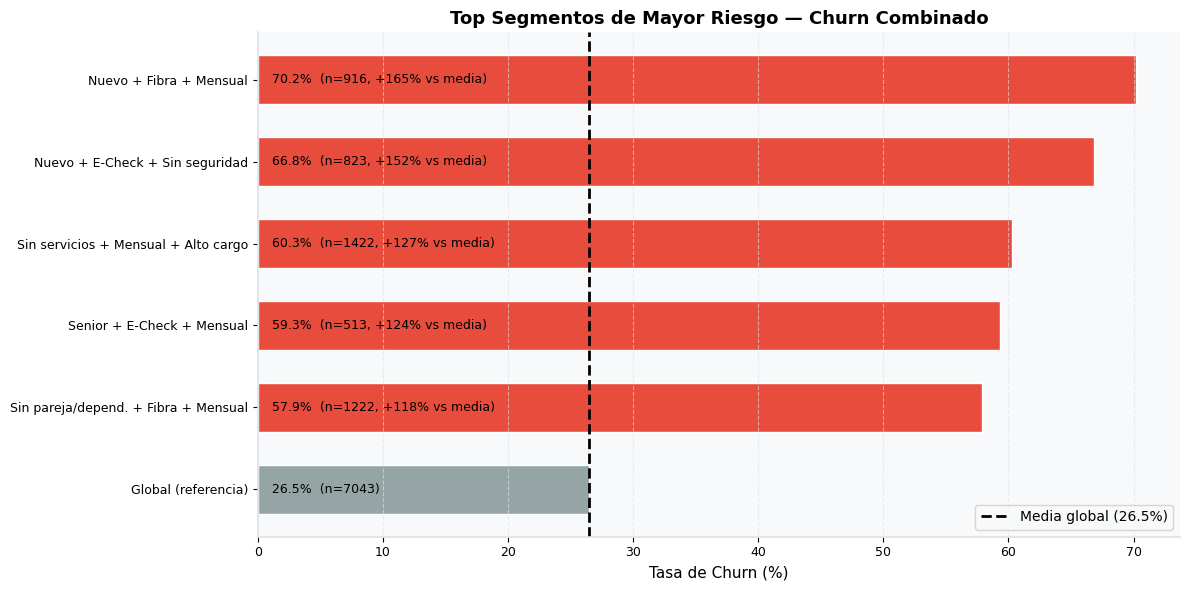

,Segmento,Tasa_Churn_pct,N_Clientes,vs_media
5,Global (referencia),26.500000,7043.000000,0.100000
3,Sin pareja/depend. + Fibra + Mensual,57.900000,1222.000000,118.300000
1,Senior + E-Check + Mensual,59.300000,513.000000,123.600000
2,Sin servicios + Mensual + Alto cargo,60.300000,1422.000000,127.400000
4,Nuevo + E-Check + Sin seguridad,66.800000,823.000000,152.200000
0,Nuevo + Fibra + Mensual,70.200000,916.000000,164.900000


In [57]:
# Segmentos combinados de mayor riesgo
segments = {
    'Nuevo + Fibra + Mensual':
        df[(df['tenure']<=12) & (df['InternetService']=='Fiber optic') &
           (df['Contract']=='Month-to-month')]['Churn_bin'].agg(['mean','count']),
    'Senior + E-Check + Mensual':
        df[(df['SeniorCitizen']==1) & (df['PaymentMethod']=='Electronic check') &
           (df['Contract']=='Month-to-month')]['Churn_bin'].agg(['mean','count']),
    'Sin servicios + Mensual + Alto cargo':
        df[(df['OnlineSecurity']=='No') & (df['TechSupport']=='No') &
           (df['Contract']=='Month-to-month') &
           (df['MonthlyCharges']>70)]['Churn_bin'].agg(['mean','count']),
    'Sin pareja/depend. + Fibra + Mensual':
        df[(df['Partner']=='No') & (df['Dependents']=='No') &
           (df['InternetService']=='Fiber optic') &
           (df['Contract']=='Month-to-month')]['Churn_bin'].agg(['mean','count']),
    'Nuevo + E-Check + Sin seguridad':
        df[(df['tenure']<=12) & (df['PaymentMethod']=='Electronic check') &
           (df['OnlineSecurity']=='No')]['Churn_bin'].agg(['mean','count']),
    'Global (referencia)':
        df['Churn_bin'].agg(['mean','count']),
}

seg_df = pd.DataFrame(segments).T.reset_index()
seg_df.columns = ['Segmento', 'Tasa_Churn', 'N_Clientes']
seg_df['Tasa_Churn_pct'] = (seg_df['Tasa_Churn'] * 100).round(1)
seg_df['vs_media'] = ((seg_df['Tasa_Churn'] / 0.265 - 1) * 100).round(1)
seg_df = seg_df.sort_values('Tasa_Churn_pct', ascending=True)

fig, ax = plt.subplots(figsize=(12, 6))
colors  = [COLOR_YES if r['Segmento'] != 'Global (referencia)' else '#95A5A6'
           for _, r in seg_df.iterrows()]
bars = ax.barh(seg_df['Segmento'], seg_df['Tasa_Churn_pct'],
               color=colors, edgecolor='white', height=0.6)
ax.axvline(26.5, color='black', linestyle='--', lw=2, label='Media global (26.5%)')
ax.set_xlabel('Tasa de Churn (%)')
ax.set_title('Top Segmentos de Mayor Riesgo — Churn Combinado',
             fontweight='bold', fontsize=13)
ax.legend()
ax.grid(True, axis='x')
for bar, row in zip(bars, seg_df.itertuples()):
    label = f'{row.Tasa_Churn_pct}%  (n={int(row.N_Clientes)}, +{row.vs_media:.0f}% vs media)'
    if row.Segmento == 'Global (referencia)':
        label = f'{row.Tasa_Churn_pct}%  (n={int(row.N_Clientes)})'
    ax.text(bar.get_height() + 0.5, bar.get_y() + bar.get_height()/2,
            label, va='center', fontsize=9)

plt.tight_layout()
plt.show()

display_table(seg_df[['Segmento','Tasa_Churn_pct','N_Clientes','vs_media']], caption='Segmentos de mayor riesgo')


**Interpretación:** El segmento "Nuevo + Fibra + Mensual" presenta tasas de churn que pueden superar el 60–70% — más del doble de la media global. Estos segmentos combinados, aunque pequeños en volumen, son los de mayor urgencia de intervención. Una campaña focalizada en el top-3 de segmentos puede capturar una fracción desproporcionada del churn total.

## 7. Análisis de Cargos y Revenue

### 7.1 Distribución de MonthlyCharges por servicio de internet

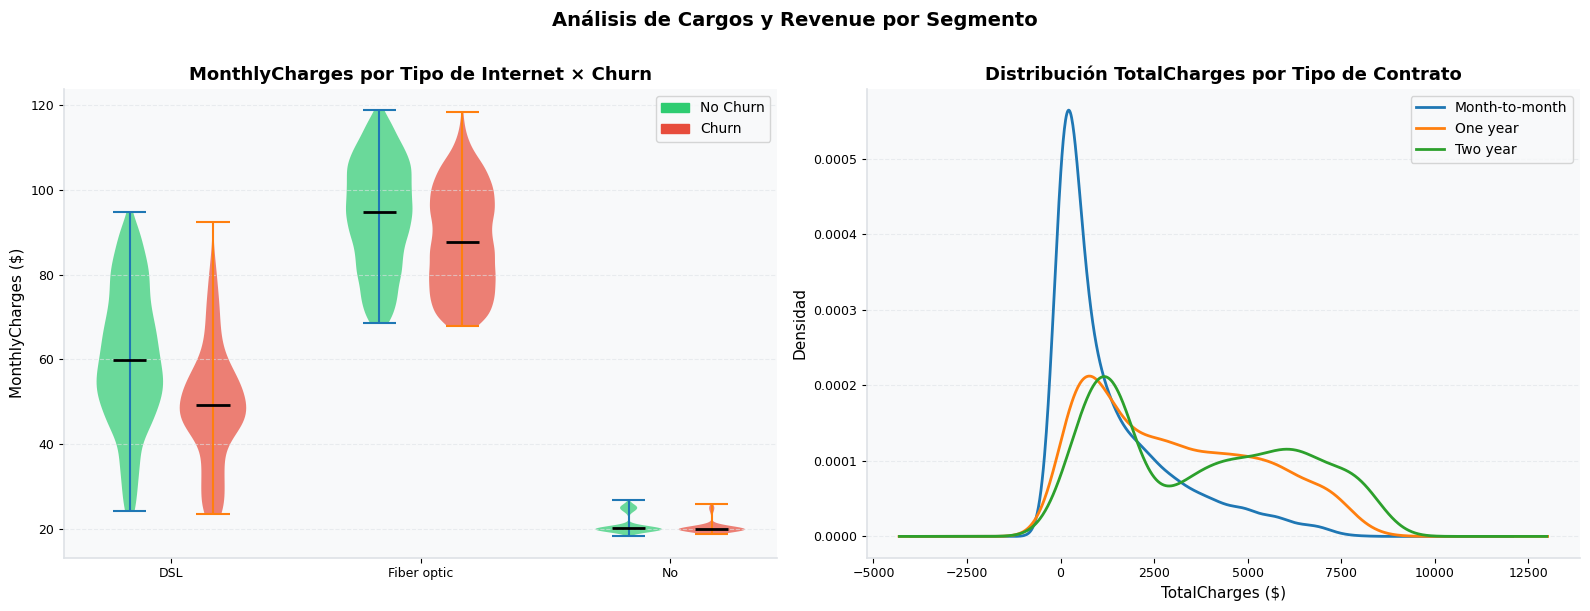

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel 1: MonthlyCharges por InternetService × Churn
internet_types = df['InternetService'].unique()
data_violin    = [df[(df['InternetService']==it) & (df['Churn']=='No')]['MonthlyCharges'].dropna()
                  for it in internet_types]
data_violin_c  = [df[(df['InternetService']==it) & (df['Churn']=='Yes')]['MonthlyCharges'].dropna()
                  for it in internet_types]

positions_no  = [1, 4, 7]
positions_yes = [2, 5, 8]

parts_no  = axes[0].violinplot(data_violin,  positions=positions_no,
                                showmedians=True, widths=0.8)
parts_yes = axes[0].violinplot(data_violin_c, positions=positions_yes,
                                showmedians=True, widths=0.8)

for pc in parts_no['bodies']:
    pc.set_facecolor(COLOR_NO); pc.set_alpha(0.7)
for pc in parts_yes['bodies']:
    pc.set_facecolor(COLOR_YES); pc.set_alpha(0.7)
for part in parts_no, parts_yes:
    part['cmedians'].set_color('black'); part['cmedians'].set_linewidth(2)

axes[0].set_xticks([1.5, 4.5, 7.5])
axes[0].set_xticklabels(internet_types, fontsize=9)
axes[0].set_ylabel('MonthlyCharges ($)')
axes[0].set_title('MonthlyCharges por Tipo de Internet × Churn')
p1 = mpatches.Patch(color=COLOR_NO,  label='No Churn')
p2 = mpatches.Patch(color=COLOR_YES, label='Churn')
axes[0].legend(handles=[p1, p2])
axes[0].grid(True, axis='y')

# Panel 2: Density plot de TotalCharges por contrato
for contract in df['Contract'].unique():
    sub = df[df['Contract']==contract]['TotalCharges'].dropna()
    sub.plot.kde(ax=axes[1], lw=2, label=contract)
axes[1].set_title('Distribución TotalCharges por Tipo de Contrato')
axes[1].set_xlabel('TotalCharges ($)')
axes[1].set_ylabel('Densidad')
axes[1].legend()
axes[1].grid(True, axis='y')

plt.suptitle('Análisis de Cargos y Revenue por Segmento',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Interpretación:** Los clientes de fibra óptica con churn tienen la mayor dispersión de MonthlyCharges, indicando que el abandono no está concentrado en un rango de precio específico sino que es un fenómeno transversal al segmento premium. Los contratos de 2 años muestran distribuciones de TotalCharges fuertemente sesgadas a la derecha — representan el mayor valor de vida del cliente (CLV).

## 8. Dashboard Resumen — Top 10 Insights

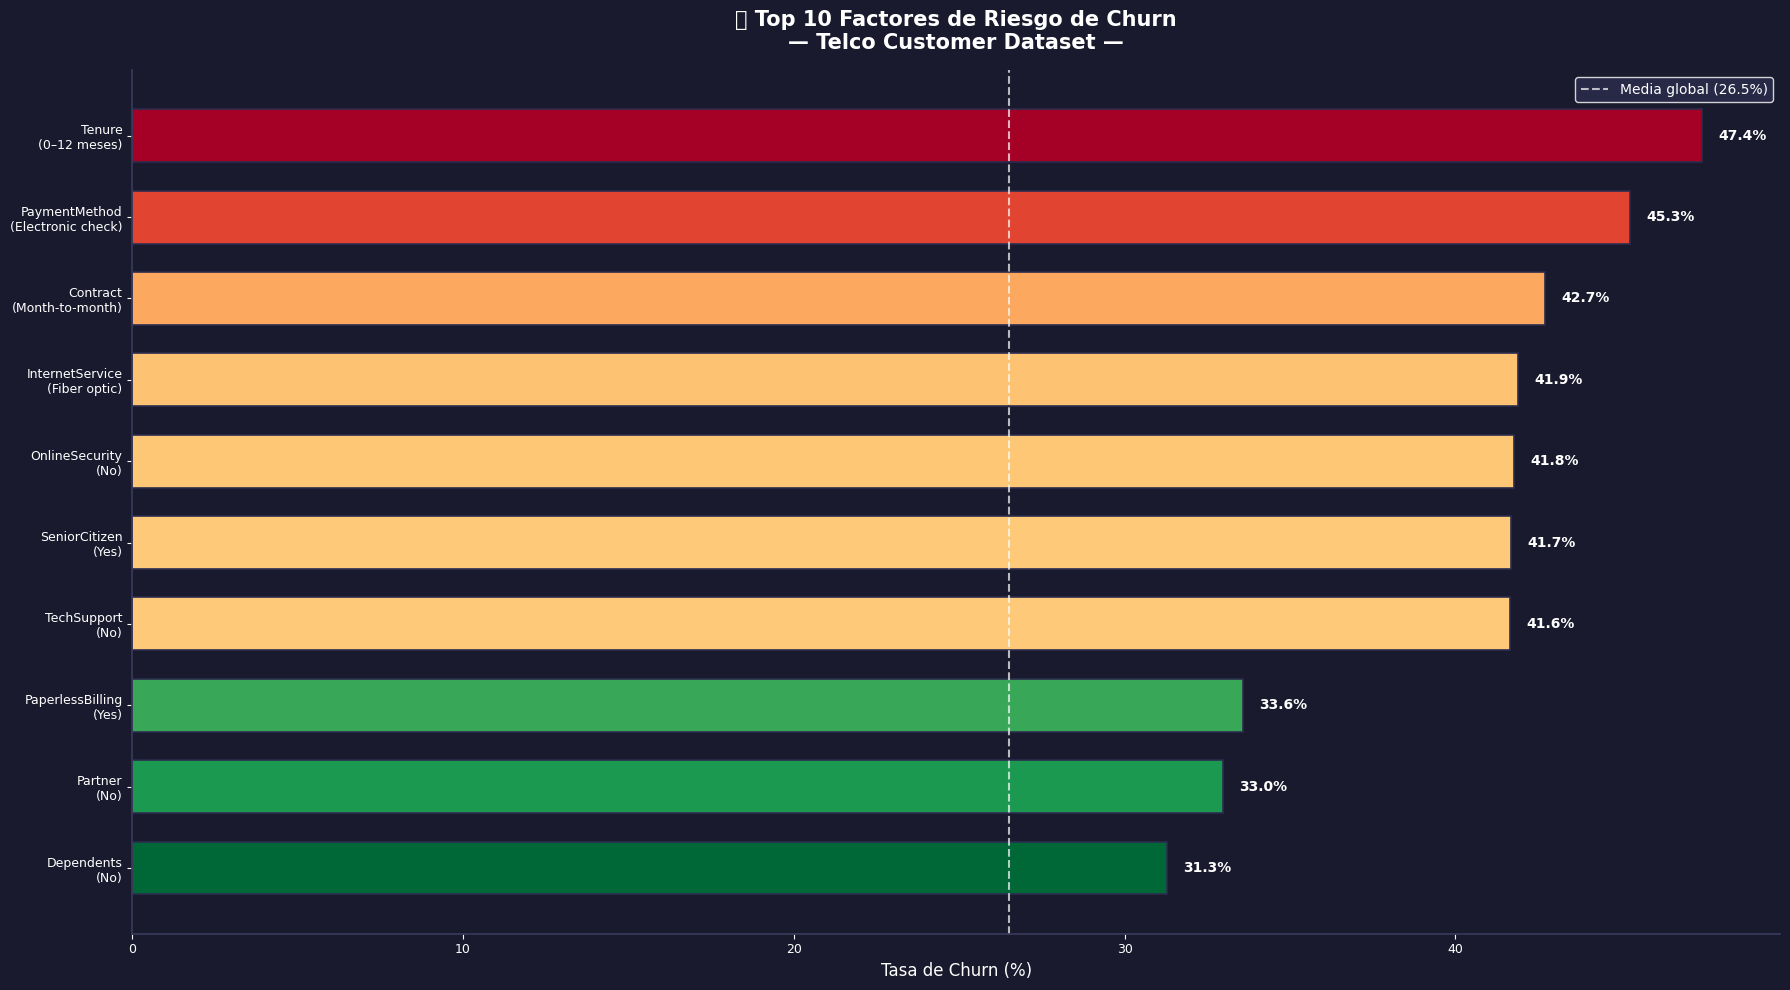

In [59]:
fig = plt.figure(figsize=(18, 10))
fig.patch.set_facecolor('#1A1A2E')

# ── Calcular top insights ────────────────────────────────────
insights = [
    ('Contract\n(Month-to-month)', df[df['Contract']=='Month-to-month']['Churn_bin'].mean()*100),
    ('InternetService\n(Fiber optic)', df[df['InternetService']=='Fiber optic']['Churn_bin'].mean()*100),
    ('PaymentMethod\n(Electronic check)', df[df['PaymentMethod']=='Electronic check']['Churn_bin'].mean()*100),
    ('OnlineSecurity\n(No)', df[df['OnlineSecurity']=='No']['Churn_bin'].mean()*100),
    ('TechSupport\n(No)', df[df['TechSupport']=='No']['Churn_bin'].mean()*100),
    ('SeniorCitizen\n(Yes)', df[df['SeniorCitizen']==1]['Churn_bin'].mean()*100),
    ('PaperlessBilling\n(Yes)', df[df['PaperlessBilling']=='Yes']['Churn_bin'].mean()*100),
    ('Partner\n(No)', df[df['Partner']=='No']['Churn_bin'].mean()*100),
    ('Tenure\n(0–12 meses)', df[df['tenure']<=12]['Churn_bin'].mean()*100),
    ('Dependents\n(No)', df[df['Dependents']=='No']['Churn_bin'].mean()*100),
]
insights_sorted = sorted(insights, key=lambda x: x[1], reverse=True)
labels_ins = [x[0] for x in insights_sorted]
values_ins = [x[1] for x in insights_sorted]

ax = fig.add_subplot(111)
ax.set_facecolor('#1A1A2E')

cmap   = plt.cm.RdYlGn_r
colors_ins = [cmap((v - min(values_ins)) / (max(values_ins) - min(values_ins)))
              for v in values_ins]

bars = ax.barh(labels_ins[::-1], values_ins[::-1],
               color=colors_ins[::-1], edgecolor='#2C2C4E',
               linewidth=1.2, height=0.65)

ax.axvline(26.5, color='white', linestyle='--', lw=1.5, alpha=0.7,
           label='Media global (26.5%)')
ax.set_xlabel('Tasa de Churn (%)', color='white', fontsize=12)
ax.set_title('🚨 Top 10 Factores de Riesgo de Churn\n— Telco Customer Dataset —',
             color='white', fontsize=15, fontweight='bold', pad=15)
ax.tick_params(colors='white', labelsize=9)
ax.spines['bottom'].set_color('#3A3A5E')
ax.spines['left'].set_color('#3A3A5E')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_facecolor('#1A1A2E')
ax.legend(facecolor='#2C2C4E', edgecolor='white',
          labelcolor='white', fontsize=10)

for bar, val in zip(bars, values_ins[::-1]):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', color='white',
            fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

## 9. Conclusiones e Insights Accionables

### 9.1 Hallazgos principales del EDA

| # | Variable | Hallazgo | Tasa de Churn | Acción sugerida |
|---|----------|----------|---------------|-----------------|
| 1 | **Contract** | Contratos mes a mes tienen ~43% de churn | 43% vs 3% (2 años) | Incentivar conversión a contratos anuales con descuento |
| 2 | **Tenure** | El 47% del churn ocurre en los primeros 12 meses | 47% en cohorte 0–12m | Onboarding activo + contacto proactivo mes 3 y 6 |
| 3 | **InternetService** | Fibra óptica concentra el mayor churn | ~42% | Auditar calidad y precio vs. competencia en fibra |
| 4 | **PaymentMethod** | E-check duplica la tasa de churn | ~45% | Ofrecer incentivos para migrar a pago automático |
| 5 | **OnlineSecurity** | Sin seguridad → 42% churn | 42% vs 15% con seguridad | Ofrecer período de prueba gratuito de seguridad online |
| 6 | **SeniorCitizen** | Adultos mayores abandonan al doble de tasa | ~42% | Programa de atención preferencial para este segmento |
| 7 | **MonthlyCharges** | Churn más alto en $70–90/mes | Media $74 vs $61 (no churn) | Revisar propuesta de valor en el rango de precio premium |

### 9.2 Perfil del cliente de mayor riesgo

> Cliente nuevo (< 12 meses) · Fibra óptica · Contrato mes a mes · Pago con cheque electrónico · Sin servicios de seguridad/soporte · Sin pareja ni dependientes · Cargo mensual > $70

Este perfil concentra tasas de churn superiores al **65%** y debe ser el objetivo prioritario de cualquier campaña de retención.

### 9.3 Variables recomendadas para el modelo predictivo
En orden de importancia según el EDA:
1. `Contract` (V de Cramér > 0.40)
2. `tenure` (correlación -0.35 con Churn)
3. `InternetService`
4. `OnlineSecurity` / `TechSupport`
5. `PaymentMethod`
6. `MonthlyCharges`
7. `SeniorCitizen`
8. `PaperlessBilling`